<a href="https://colab.research.google.com/github/amscally-dsci/Data-Science-Cohort-20/blob/main/Project-4/Project_4_DRAFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

Predict the popularity of a new song using data from Spotify’s Top 200 Weekly Global Charts (2020 & 2021).
* Use a tree-based regression model trained on the Spotify data set features.
* Minimize the root mean squared error ( RMSE )
* Determine feature importance


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

pd.set_option('display.max_columns', None)

## Read in Data

### Initial Data Analysis (IDA)

In [2]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: Xomw594mCGu7kb+FlJFxSutiqWLscE9oJckWWwthf5brHwHgf7msPmkFrY7Po9pZX0a42zJiP3s0Ye2xI52myIp/WbHYepEq
x-amz-request-id: 50P4NW4G7D8G4H88
Date: Mon, 15 Jun 2026 20:14:31 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [3]:
# download the file to the virtual machine to index column headers
!curl -s -O {url}

In [4]:
# confirmation the csv is downloaded to VM instance
%ls -la

total 740
drwxr-xr-x 1 root root   4096 Jun 15 20:14 ./
drwxr-xr-x 1 root root   4096 Jun 15 19:23 ../
drwxr-xr-x 4 root root   4096 Jun  4 13:32 .config/
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data/
-rw-r--r-- 1 root root 738124 Jun 15 20:14 Spotify.csv


In [5]:
# Grabs first line of csv file (headers/field names), replaces commas with new lines,
# and numbers every line so every coliumn name is on a separate line
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


In [6]:
spotify_df=pd.read_csv(url,index_col=0)

In [7]:
spotify_df.head()

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
Index,,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb


In [8]:
spotify_df.shape


(1556, 22)

In [9]:
spotify_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Highest Charting Position  1556 non-null   int64 
 1   Number of Times Charted    1556 non-null   int64 
 2   Week of Highest Charting   1556 non-null   object
 3   Song Name                  1556 non-null   object
 4   Streams                    1556 non-null   object
 5   Artist                     1556 non-null   object
 6   Artist Followers           1556 non-null   object
 7   Song ID                    1556 non-null   object
 8   Genre                      1556 non-null   object
 9   Release Date               1556 non-null   object
 10  Weeks Charted              1556 non-null   object
 11  Popularity                 1556 non-null   object
 12  Danceability               1556 non-null   object
 13  Energy                     1556 non-null   object
 14  Loudness     

## Data Cleaning

In [10]:
spotify_df['Tempo']

,Tempo
Index,
1,134.002
2,169.928
3,166.928
4,126.026
5,149.995
...,...
1552,116.073
1553,152.37
1554,104.988


In [11]:
## spotify_df['Tempo'].astype("float")

In [12]:
# 11 rows that have spaces them
(spotify_df['Tempo']==' ').sum()

np.int64(11)

In [13]:
spotify_df[['Tempo']].replace(' ',np.nan).astype('float').dropna()

,Tempo
Index,
1,134.002
2,169.928
3,166.928
4,126.026
5,149.995
...,...
1552,116.073
1553,152.370
1554,104.988


In [15]:
# adding new column to DF which contains Tempo column entries but transformed into floats and sans white space/nulls.
spotify_df['Tempo_float'] = spotify_df[['Tempo']].replace(' ',np.nan).astype('float')

In [16]:
spotify_df.head()

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord,Tempo_float
Index,,,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B,134.002
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db,169.928
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A,166.928
4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B,126.026
5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb,149.995


In [17]:
spotify_df.shape

(1556, 23)

In [18]:
spotify_df['Energy_float'] = spotify_df['Energy'].replace(' ',np.nan).astype('float')
spotify_df

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord,Tempo_float,Energy_float
Index,,,,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B,134.002,0.800
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db,169.928,0.764
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A,166.928,0.664
4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B,126.026,0.897
5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb,149.995,0.704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",2017-06-02,2019-12-27--2020-01-03,79,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A,116.073,0.700
1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",2019-10-11,2019-12-27--2020-01-03,66,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B,152.370,0.870
1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",2018-01-12,2019-12-27--2020-01-03,81,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D,104.988,0.523


In [19]:
spotify_df['Danceability']

,Danceability
Index,
1,0.714
2,0.591
3,0.563
4,0.808
5,0.736
...,...
1552,0.762
1553,0.528
1554,0.765


In [20]:
spotify_df['Danceability_float'] = spotify_df['Danceability'].replace(' ',np.nan).astype('float')
spotify_df

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord,Tempo_float,Energy_float,Danceability_float
Index,,,,,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B,134.002,0.800,0.714
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db,169.928,0.764,0.591
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A,166.928,0.664,0.563
4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B,126.026,0.897,0.808
5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb,149.995,0.704,0.736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",2017-06-02,2019-12-27--2020-01-03,79,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A,116.073,0.700,0.762
1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",2019-10-11,2019-12-27--2020-01-03,66,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B,152.370,0.870,0.528
1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",2018-01-12,2019-12-27--2020-01-03,81,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D,104.988,0.523,0.765


In [21]:
## spotify_df['Artist Followers'].astype('Int64')

In [22]:
spotify_df['Artist Followers_int']=spotify_df[['Artist Followers']].replace(' ',np.nan).astype('Int64')
spotify_df

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord,Tempo_float,Energy_float,Danceability_float,Artist Followers_int
Index,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B,134.002,0.800,0.714,3377762
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db,169.928,0.764,0.591,2230022
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A,166.928,0.664,0.563,6266514
4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B,126.026,0.897,0.808,83293380
5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb,149.995,0.704,0.736,5473565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",2017-06-02,2019-12-27--2020-01-03,79,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A,116.073,0.700,0.762,27167675
1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",2019-10-11,2019-12-27--2020-01-03,66,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B,152.370,0.870,0.528,15019109
1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",2018-01-12,2019-12-27--2020-01-03,81,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D,104.988,0.523,0.765,22698747


In [23]:
pd.get_dummies(spotify_df, columns=['Chord'], dtype=int).drop(columns=['Chord_ ']).columns


Index(['Highest Charting Position', 'Number of Times Charted',
       'Week of Highest Charting', 'Song Name', 'Streams', 'Artist',
       'Artist Followers', 'Song ID', 'Genre', 'Release Date', 'Weeks Charted',
       'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness',
       'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence',
       'Tempo_float', 'Energy_float', 'Danceability_float',
       'Artist Followers_int', 'Chord_A', 'Chord_A#/Bb', 'Chord_B', 'Chord_C',
       'Chord_C#/Db', 'Chord_D', 'Chord_D#/Eb', 'Chord_E', 'Chord_F',
       'Chord_F#/Gb', 'Chord_G', 'Chord_G#/Ab'],
      dtype='object')

### Target

In [24]:
## spotify_df['Popularity'].astype('int')

In [25]:
spotify_df[['Popularity']].replace(' ',np.nan).astype('Int64')

,Popularity
Index,
1,100
2,99
3,99
4,98
5,96
...,...
1552,79
1553,66
1554,81


In [26]:
spotify_df['Popularity_int'] = spotify_df[['Popularity']].replace(' ',np.nan).astype('Int64')

In [27]:
spotify_df.head()

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord,Tempo_float,Energy_float,Danceability_float,Artist Followers_int,Popularity_int
Index,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B,134.002,0.800,0.714,3377762,100
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db,169.928,0.764,0.591,2230022,99
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A,166.928,0.664,0.563,6266514,99
4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B,126.026,0.897,0.808,83293380,98
5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb,149.995,0.704,0.736,5473565,96


### Selecting Features

In [28]:
clean_df=(
    spotify_df[['Popularity_int','Tempo_float','Energy_float','Danceability_float','Artist Followers_int','Chord']]
    .dropna()
    .pipe(pd.get_dummies,columns=['Chord'],dtype=int)
    .copy()
)
clean_df

,Popularity_int,Tempo_float,Energy_float,Danceability_float,Artist Followers_int,Chord_A,Chord_A#/Bb,Chord_B,Chord_C,Chord_C#/Db,Chord_D,Chord_D#/Eb,Chord_E,Chord_F,Chord_F#/Gb,Chord_G,Chord_G#/Ab
Index,,,,,,,,,,,,,,,,,
1,100,134.002,0.800,0.714,3377762,0,0,1,0,0,0,0,0,0,0,0,0
2,99,169.928,0.764,0.591,2230022,0,0,0,0,1,0,0,0,0,0,0,0
3,99,166.928,0.664,0.563,6266514,1,0,0,0,0,0,0,0,0,0,0,0
4,98,126.026,0.897,0.808,83293380,0,0,1,0,0,0,0,0,0,0,0,0
5,96,149.995,0.704,0.736,5473565,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,79,116.073,0.700,0.762,27167675,1,0,0,0,0,0,0,0,0,0,0,0
1553,66,152.370,0.870,0.528,15019109,0,0,1,0,0,0,0,0,0,0,0,0
1554,81,104.988,0.523,0.765,22698747,0,0,0,0,0,1,0,0,0,0,0,0


In [29]:
# Clean DF with target and feature both int or float.
clean_df.head()

,Popularity_int,Tempo_float,Energy_float,Danceability_float,Artist Followers_int,Chord_A,Chord_A#/Bb,Chord_B,Chord_C,Chord_C#/Db,Chord_D,Chord_D#/Eb,Chord_E,Chord_F,Chord_F#/Gb,Chord_G,Chord_G#/Ab
Index,,,,,,,,,,,,,,,,,
1,100,134.002,0.800,0.714,3377762,0,0,1,0,0,0,0,0,0,0,0,0
2,99,169.928,0.764,0.591,2230022,0,0,0,0,1,0,0,0,0,0,0,0
3,99,166.928,0.664,0.563,6266514,1,0,0,0,0,0,0,0,0,0,0,0
4,98,126.026,0.897,0.808,83293380,0,0,1,0,0,0,0,0,0,0,0,0
5,96,149.995,0.704,0.736,5473565,0,0,0,0,0,0,1,0,0,0,0,0


In [30]:
clean_df.shape

(1545, 17)

In [31]:
clean_df.isnull().sum()*1000


,0
Popularity_int,0
Tempo_float,0
Energy_float,0
Danceability_float,0
Artist Followers_int,0
Chord_A,0
Chord_A#/Bb,0
Chord_B,0
Chord_C,0
Chord_C#/Db,0


## Decision Tree Regression

PROS
*
*
*

CONS
* Does not handle outliers well


In [32]:
# X is all the features sans target
# y is the target only (Popularity)
X = clean_df.drop('Popularity_int', axis = 1)
y = clean_df['Popularity_int'] ## looking at target which is a data series (not a column)
X.shape,y.shape

((1545, 16), (1545,))

In [33]:
X.columns

Index(['Tempo_float', 'Energy_float', 'Danceability_float',
       'Artist Followers_int', 'Chord_A', 'Chord_A#/Bb', 'Chord_B', 'Chord_C',
       'Chord_C#/Db', 'Chord_D', 'Chord_D#/Eb', 'Chord_E', 'Chord_F',
       'Chord_F#/Gb', 'Chord_G', 'Chord_G#/Ab'],
      dtype='object')

In [34]:
# Cross validation (CV) loop
# Creating a baseline

numLoops = 100

rms_error = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  # line 10: Providing hyperparamter like Lasso and Ridge--affects how the model works
  model = DecisionTreeRegressor(max_depth=3)         # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)}")


CV RMSE: 11.11


## How do we choose the tree depth?

In [35]:
max_depths = [1,2,3,4,5,6,7,8,9,10]
rms_depth = np.zeros(len(max_depths))
std_depth = np.zeros(len(max_depths))

numLoops = 100

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std( ddof = 1 )


In [36]:
pd.DataFrame( zip( max_depths, rms_depth, std_depth ), columns = 'A B C'.split() )


,A,B,C
0,1,15.182499,1.024998
1,2,11.032970,0.972339
2,3,11.110838,0.689158
3,4,11.008637,0.706376
4,5,11.169841,0.724494
5,6,11.371828,0.757252
6,7,11.363972,0.853998
7,8,11.485142,0.832938
8,9,11.874127,0.889152
9,10,12.085944,0.819748


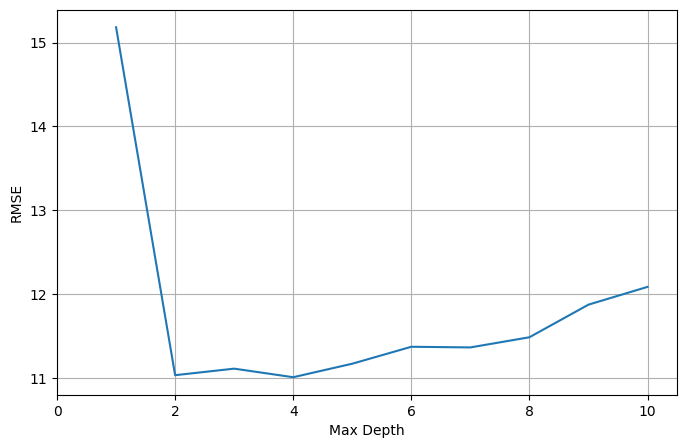

In [37]:
# Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()


In [38]:
# Re run with max depth = 4
numLoops = 500

rms_error = np.zeros( numLoops )

for idx in range( 0, numLoops ):
  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2 )
  model = DecisionTreeRegressor( max_depth=4 )
  model.fit( X_train, y_train )
  y_pred = model.predict( X_test )
  rms_error[idx] = np.sqrt( mean_squared_error( y_test, y_pred ) )

print(f"CV RMSE: {rms_error.mean().round(2)}")


CV RMSE: 11.02


# Visualize the Decision Tree

In [39]:
import graphviz
from IPython.display import display
from sklearn import tree

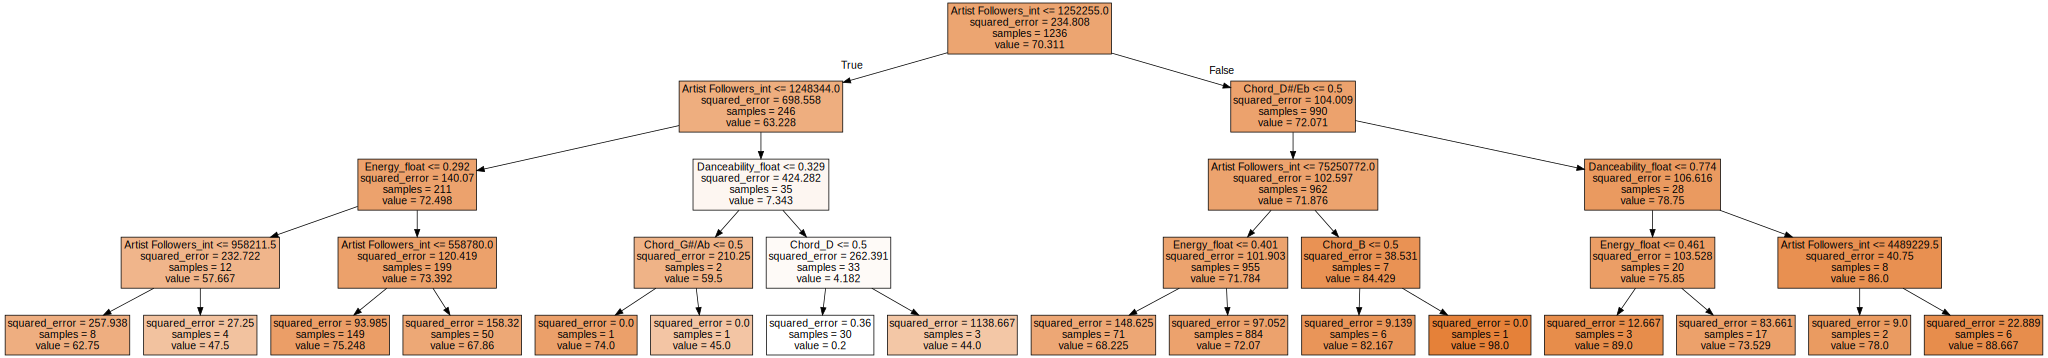

In [40]:
# Option 1
display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )
  )
)


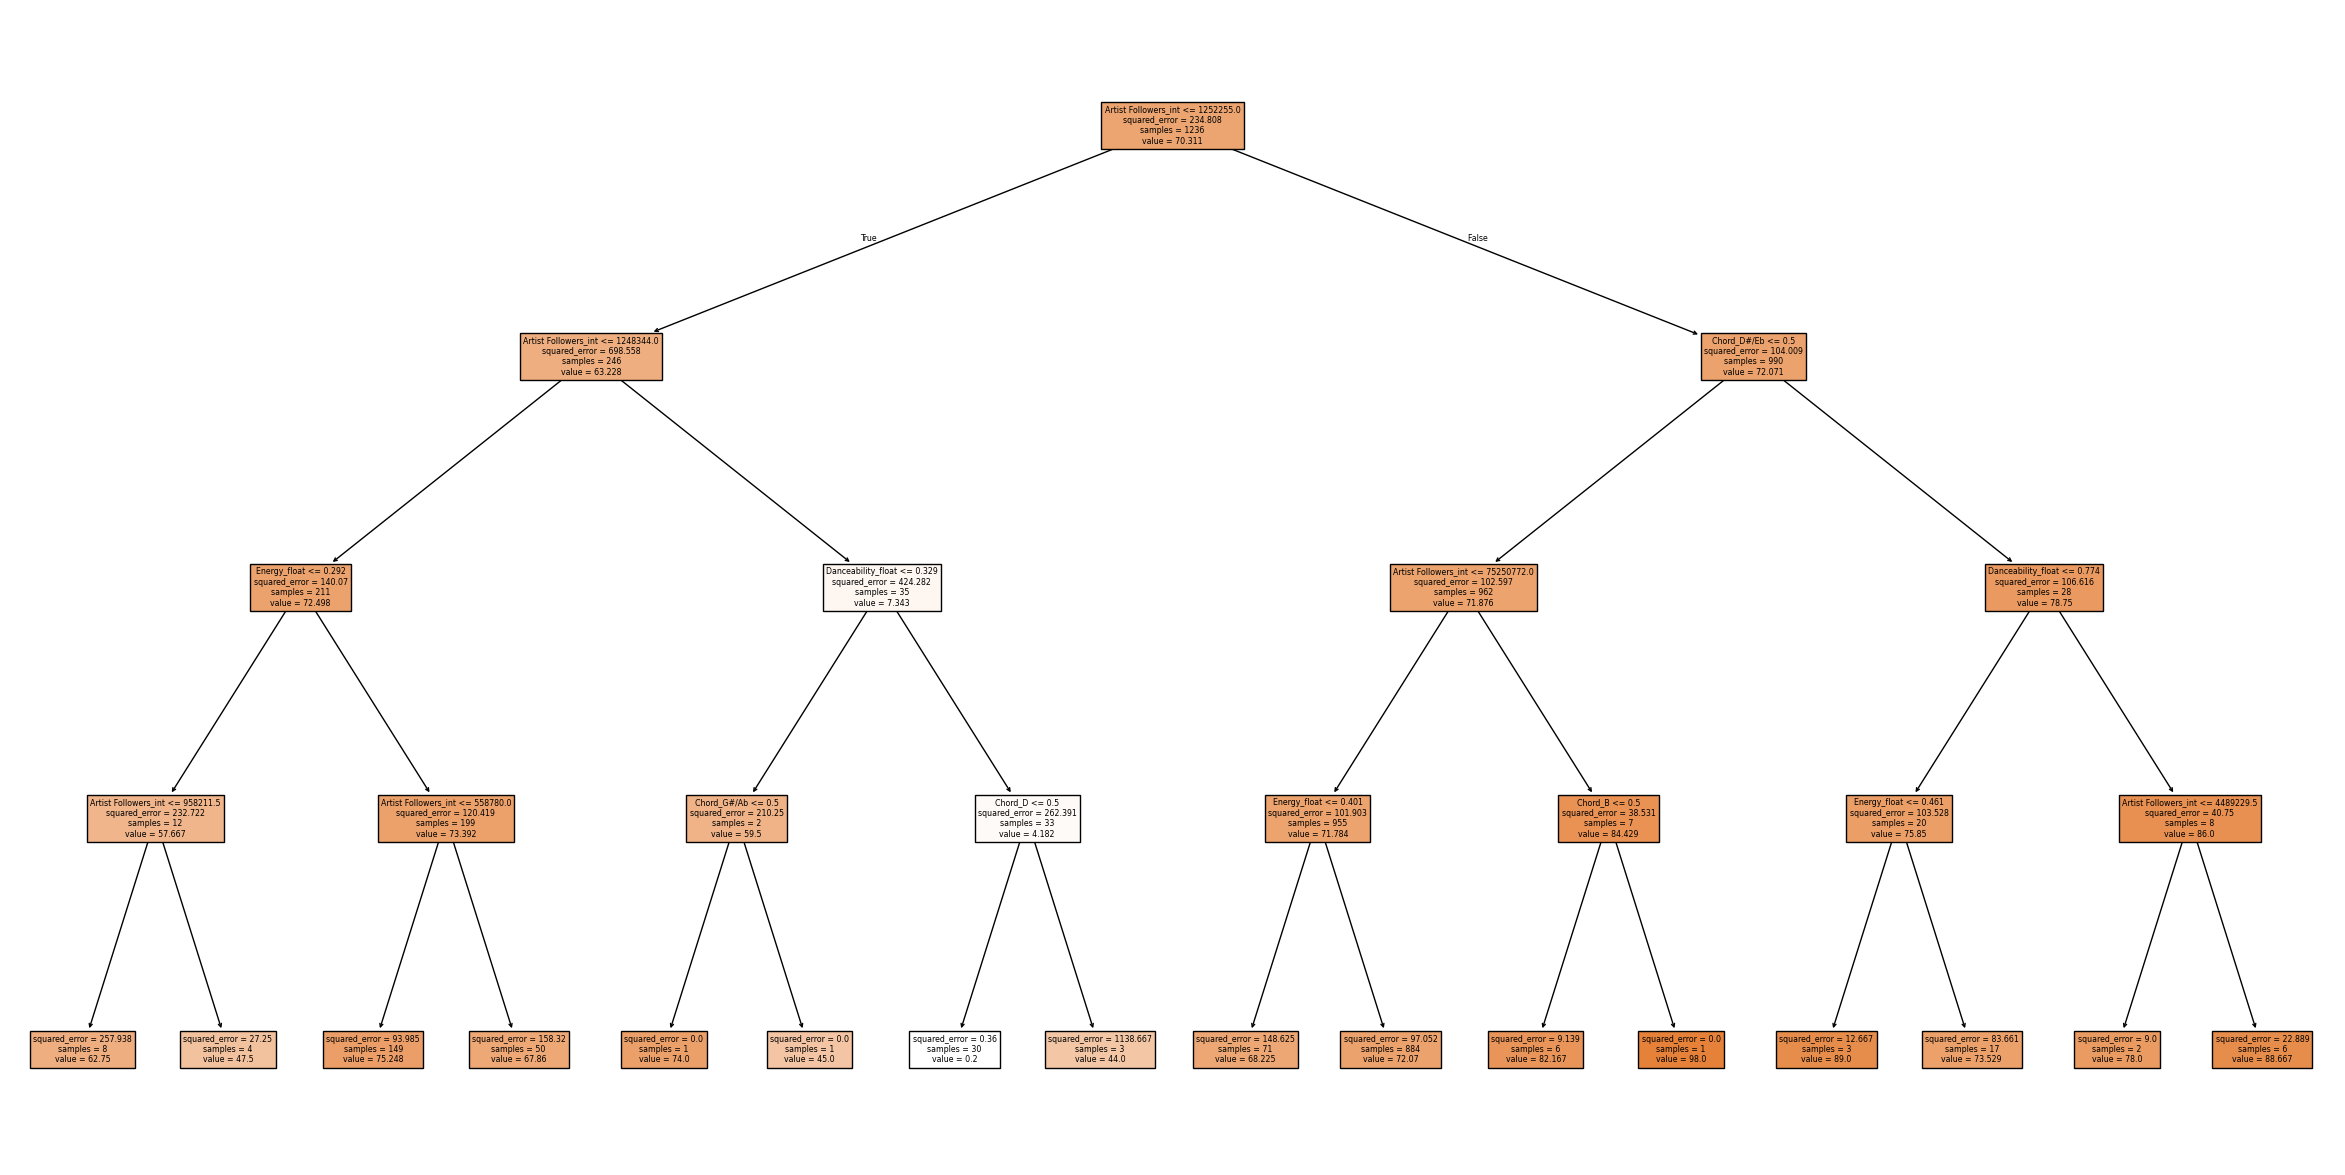

In [41]:
# Option 2
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)


## Find Important Predictors

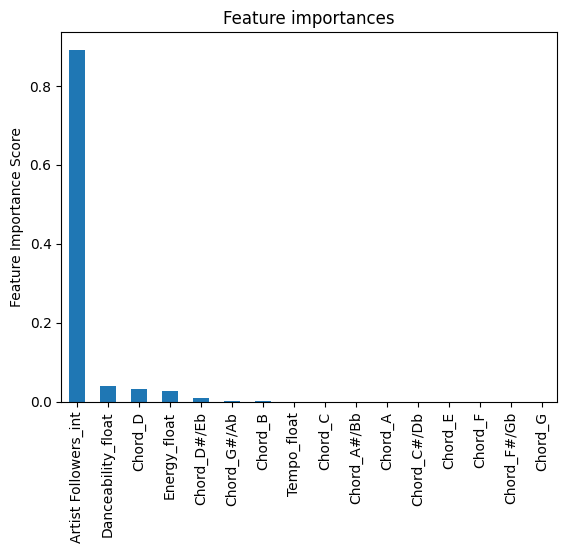

In [42]:
importances = model.feature_importances_
tree_importances = pd.Series( importances, index = X.columns )

plt.figure()
# tree_importances.plot.bar()
tree_importances.sort_values( ascending = False ).plot.bar()
plt.title("Feature importances")
plt.ylabel('Feature Importance Score') ;


In [48]:
( tree_importances.sort_values( ascending = False )* 100)


,0
Artist Followers_int,89.135352
Danceability_float,3.861369
Chord_D,3.177000
Energy_float,2.659885
Chord_D#/Eb,0.780584
Chord_G#/Ab,0.255333
Chord_B,0.130478
Tempo_float,0.000000
Chord_C,0.000000
Chord_A#/Bb,0.000000
